In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
   # for filename in filenames:
       # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [16]:
!pip install matplotlib
!pip install --upgrade librosa

In [17]:
import os
import numpy as np
import pandas as pd
import librosa
base_path="/kaggle/input/datasets/soumyadebmukherjee/heart-and-lung-sounds-dataset/HLS-CMDS Heart and Lung Sounds Dataset Recorded from a Clinical Manikin using Digital Stethoscope"
mix_path=base_path+"/Mix/Mix"
files=os.listdir(mix_path)
print("Total files:",len(files))
print(files[:10])

Total files: 436
['M0115.wav', 'H0104.wav', 'H0013.wav', 'L0070.wav', 'H0017.wav', 'L0024.wav', 'M0109.wav', 'H0109.wav', 'H0002.wav', 'H0108.wav']


In [18]:
import librosa
file_path=mix_path+'/'+files[0]
y,sr=librosa.load(file_path,sr=None)
print("Shape:",y.shape)
print("Sample rate:",sr)

Shape: (60000,)
Sample rate: 4000


In [19]:
import IPython.display as ipd
ipd.Audio(file_path)

In [20]:
def add_noise(audio):
    noise = 0.005 * np.random.randn(len(audio))
    return audio + noise

def time_shift(audio):
    shift = int(0.1 * len(audio))
    return np.roll(audio, shift)

def pitch_shift(audio, sr):
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)

X = []
y = []

df['file_name'] = df['Mixed Sound ID'] + ".wav"

for i in range(len(df)):
    try:
        file = df['file_name'][i]
        file_path = os.path.join(mix_path, file)

        audio, sr = librosa.load(file_path, sr=None)

        audios = [
            audio,
            add_noise(audio),
            time_shift(audio),
            pitch_shift(audio, sr)
        ]
        for aug_audio in audios:

            mel = librosa.feature.melspectrogram(y=aug_audio, sr=sr, n_mels=128)
            mel_db = librosa.power_to_db(mel)

            mfcc = librosa.feature.mfcc(y=aug_audio, sr=sr, n_mfcc=40)

            # combine
            combined = np.vstack([mel_db, mfcc])

            # resize
            if combined.shape[1] < 128:
                pad = 128 - combined.shape[1]
                combined = np.pad(combined, ((0,0),(0,pad)), mode='constant')
            else:
                combined = combined[:, :128]

            combined = combined[:128, :]

            X.append(combined)
            y.append(df['Lung Sound Type'][i])
    except Exception as e:
        print("Error:", e)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)

X shape: (580, 128, 128)


In [21]:
import pandas as pd
df=pd.read_csv(base_path+"/Mix.csv")
df.head

<bound method NDFrame.head of     Gender       Heart Sound Type  Lung Sound Type Location Heart Sound ID  \
0        F   Late Systolic Murmur          Rhonchi     LUSB          H0001   
1        F                     S3           Normal      RLA          H0002   
2        M    Atrial Fibrillation           Normal      LMA          H0003   
3        F                     S3  Coarse Crackles     Apex          H0004   
4        M               AV Block    Fine Crackles     RUSB          H0005   
..     ...                    ...              ...      ...            ...   
140      M                     S4         Wheezing     Apex          H0141   
141      F    Mid Systolic Murmur           Normal      RMA          H0142   
142      F  Early Systolic Murmur         Wheezing      RLA          H0143   
143      F               AV Block           Normal      LUA          H0144   
144      M  Late Diastolic Murmur           Normal     RUSB          H0145   

    Lung Sound ID Mixed Sound ID 

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

num_classes = len(le.classes_)
print(le.classes_)

['Coarse Crackles' 'Fine Crackles' 'Normal' 'Pleural Rub' 'Rhonchi'
 'Wheezing']


In [23]:
#normalize and train
X = (X - np.mean(X)) / np.std(X)

X = X.reshape(X.shape[0], 128, 128, 1)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [28]:
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape=(128,128,1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [31]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/40


I0000 00:00:1776617216.963340     183 service.cc:152] XLA service 0x7a2470007790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776617216.963405     183 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776617216.963412     183 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776617217.523386     183 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-19 16:46:59.560175: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 16:46:59.705365: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 8/29 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1135 - loss: 8.3066

I0000 00:00:1776617222.678671     183 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.1579 - loss: 5.8002 - val_accuracy: 0.2155 - val_loss: 2.1088
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2746 - loss: 1.7924 - val_accuracy: 0.1466 - val_loss: 4.2628
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3080 - loss: 1.6649 - val_accuracy: 0.1466 - val_loss: 3.1010
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2919 - loss: 1.6011 - val_accuracy: 0.1466 - val_loss: 3.0128
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4163 - loss: 1.4692 - val_accuracy: 0.1638 - val_loss: 2.2798
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4981 - loss: 1.2722 - val_accuracy: 0.2672 - val_loss: 2.1595


In [33]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step - accuracy: 0.2018 - loss: 2.1227
Accuracy: 0.21551723778247833


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step


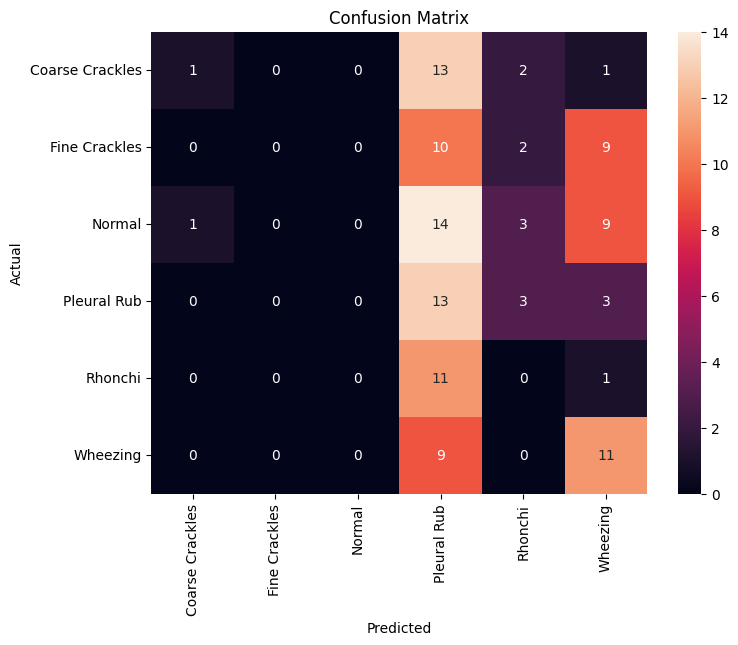

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

This project classifies lung diseases using audio recordings.
We convert audio signals into MFCC features and train a machine learning model to predict disease types.